### Подготовка данных

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [ ]:
# Загрузка файлов
df_subscription = pd.read_csv('/content/subscription_plans_and_retention.csv')
df_user_events = pd.read_csv('/content/user_event_data_streaming_mini.csv')
print("✅ с кайфом загрузили данные !")

✅ с кайфом загрузили данные !


### Сегментация пользователей
Сегменты пользователей
- Paid (в events есть purchase_events 'purchase_quarterly', 'purchase_annual', 'purchase_monthly', 'renew')
  - Paid active ( число событий 'add_to_playlist' > 4)
  - Paid low engagement ( число событий 'add_to_playlist' < 4)
- Trial user ( есть 'start_premium_trial' в events )
- Free active ( число событий 'add_to_playlist' > 4)
- Free low engagement ( число событий 'add_to_playlist' < 4)
- Churned paid ( есть cancel в events)

In [ ]:
# Проверка уникальных значений в колонках
print("\nУникальные события в events:")
print(df_user_events['event'].unique())

print("\nУникальные группы в events:")
print(df_user_events['group'].unique())

print("\nУникальные сегменты контента в events:")
print(df_user_events['content_segment'].unique())

# Анализ распределения событий по типам
event_counts = df_user_events['event'].value_counts()
print("\nРаспределение событий по типам:")
print(event_counts)


Уникальные события в events:
['add_to_playlist' 'start_premium_trial' 'purchase_quarterly' 'renew'
 'purchase_annual' 'purchase_monthly' 'cancel']

Уникальные группы в events:
['test' 'control']

Уникальные сегменты контента в events:
['Music' 'All' 'Podcast' 'Mix']

Распределение событий по типам:
event
add_to_playlist        3006
start_premium_trial     836
renew                   676
purchase_monthly        593
purchase_quarterly      201
cancel                  196
purchase_annual          78
Name: count, dtype: int64


In [ ]:
# Платные события
purchase_events = ['purchase_quarterly', 'purchase_annual', 'purchase_monthly', 'renew']

# Функция классификации пользователей
def classify_user(user_data):
    events = user_data['event'].tolist()
    user_id = user_data['user_id'].iloc[0]

    # Проверяем, есть ли платные события
    has_paid = any(event in purchase_events for event in events)

    # Проверяем, есть ли trial
    has_trial = 'start_premium_trial' in events

    # Проверяем, есть ли отмена
    has_cancel = 'cancel' in events

    # Считаем активность (add_to_playlist)
    activity_count = events.count('add_to_playlist')

    # Классификация по правилам
    if has_cancel:
        # Если пользователь отменил подписку, проверяем был ли он платным
        if has_paid:
            return 'Churned paid'
        elif has_trial:
            return 'Churned trial'
        else:
            return 'Churned free'
    elif has_paid:
        return 'Paid active'
    elif has_trial:
        return 'Trial user'
    elif activity_count >= 3:  # Порог для активных пользователей
        return 'Free active'
    else:
        return 'Free low engagement'

# Группируем данные по пользователям и применяем классификацию
user_segments = df_user_events.groupby('user_id').apply(classify_user).reset_index()
user_segments.columns = ['user_id', 'segment']

# Объединяем сегменты с исходными данными
df_user_events = df_user_events.merge(user_segments, on='user_id')

# Анализируем распределение пользователей по сегментам
segment_distribution = user_segments['segment'].value_counts()
print("Распределение пользователей по сегментам:")
print(segment_distribution)

# Дополнительный анализ по группам (test/control)
segment_group_analysis = pd.crosstab(user_segments['segment'], df_user_events.groupby('user_id')['group'].first())
print("\nРаспределение сегментов по группам:")
print(segment_group_analysis)

# Анализ по сегментам контента
content_segment_analysis = pd.crosstab(user_segments['segment'], df_user_events.groupby('user_id')['content_segment'].agg(lambda x: x.mode()[0] if not x.mode().empty else 'Unknown'))
print("\nСвязь сегментов пользователей с сегментами контента:")
print(content_segment_analysis)

# Анализ оттока (churn) по разным категориям
churn_users = user_segments[user_segments['segment'].str.contains('Churned')]
print(f"\nОбщее количество оттока: {len(churn_users)}")

# Детальный анализ оттока
churn_analysis = pd.crosstab(
    churn_users['segment'],
    df_user_events[df_user_events['user_id'].isin(churn_users['user_id'])].groupby('user_id')['group'].first()
)
print("\nАнализ оттока по группам:")
print(churn_analysis)

# Анализ контента для оттока
churn_content_analysis = pd.crosstab(
    churn_users['segment'],
    df_user_events[df_user_events['user_id'].isin(churn_users['user_id'])].groupby('user_id')['content_segment'].agg(lambda x: x.mode()[0] if not x.mode().empty else 'Unknown')
)
print("\nАнализ оттока по сегментам контента:")
print(churn_content_analysis)

Распределение пользователей по сегментам:
segment
Paid active            676
Churned paid           196
Free active             65
Free low engagement     50
Trial user               8
Name: count, dtype: int64

Распределение сегментов по группам:
group                control  test
segment                           
Churned paid              97    98
Free active               37    28
Free low engagement       19    31
Paid active              333   338
Trial user                 6     2


/tmp/ipython-input-2345088503.py:40: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  user_segments = df_user_events.groupby('user_id').apply(classify_user).reset_index()



Связь сегментов пользователей с сегментами контента:
content_segment      All  Mix  Music  Podcast
segment                                      
Churned paid         102   12     57       24
Free active           33    2     20       10
Free low engagement   32    3      7        8
Paid active          377   50    178       66
Trial user             1    2      4        1

Общее количество оттока: 196

Анализ оттока по группам:
group         control  test
segment                    
Churned paid       28    20

Анализ оттока по сегментам контента:
content_segment  All  Mix  Music  Podcast
segment                                  
Churned paid      30    4     10        4


### Когортный анализ

COHORT ANALYSIS: USER RETENTION PATTERNS

Cohort Sizes (Number of Users):
cohort
Week 1    351
Week 2    247
Week 3    138
Week 4    115
Week 5     29
Name: 1, dtype: int64

Retention Matrix (% of Cohort Active Each Week):
activity_week      1     2     3     4     5
cohort                                      
Week 1         100.0  52.7  56.7  85.5  33.6
Week 2         100.0  56.3  81.0  47.0   0.0
Week 3         100.0  79.0  48.6   0.0   0.0
Week 4         100.0  49.6   0.0   0.0   0.0
Week 5         100.0   0.0   0.0   0.0   0.0


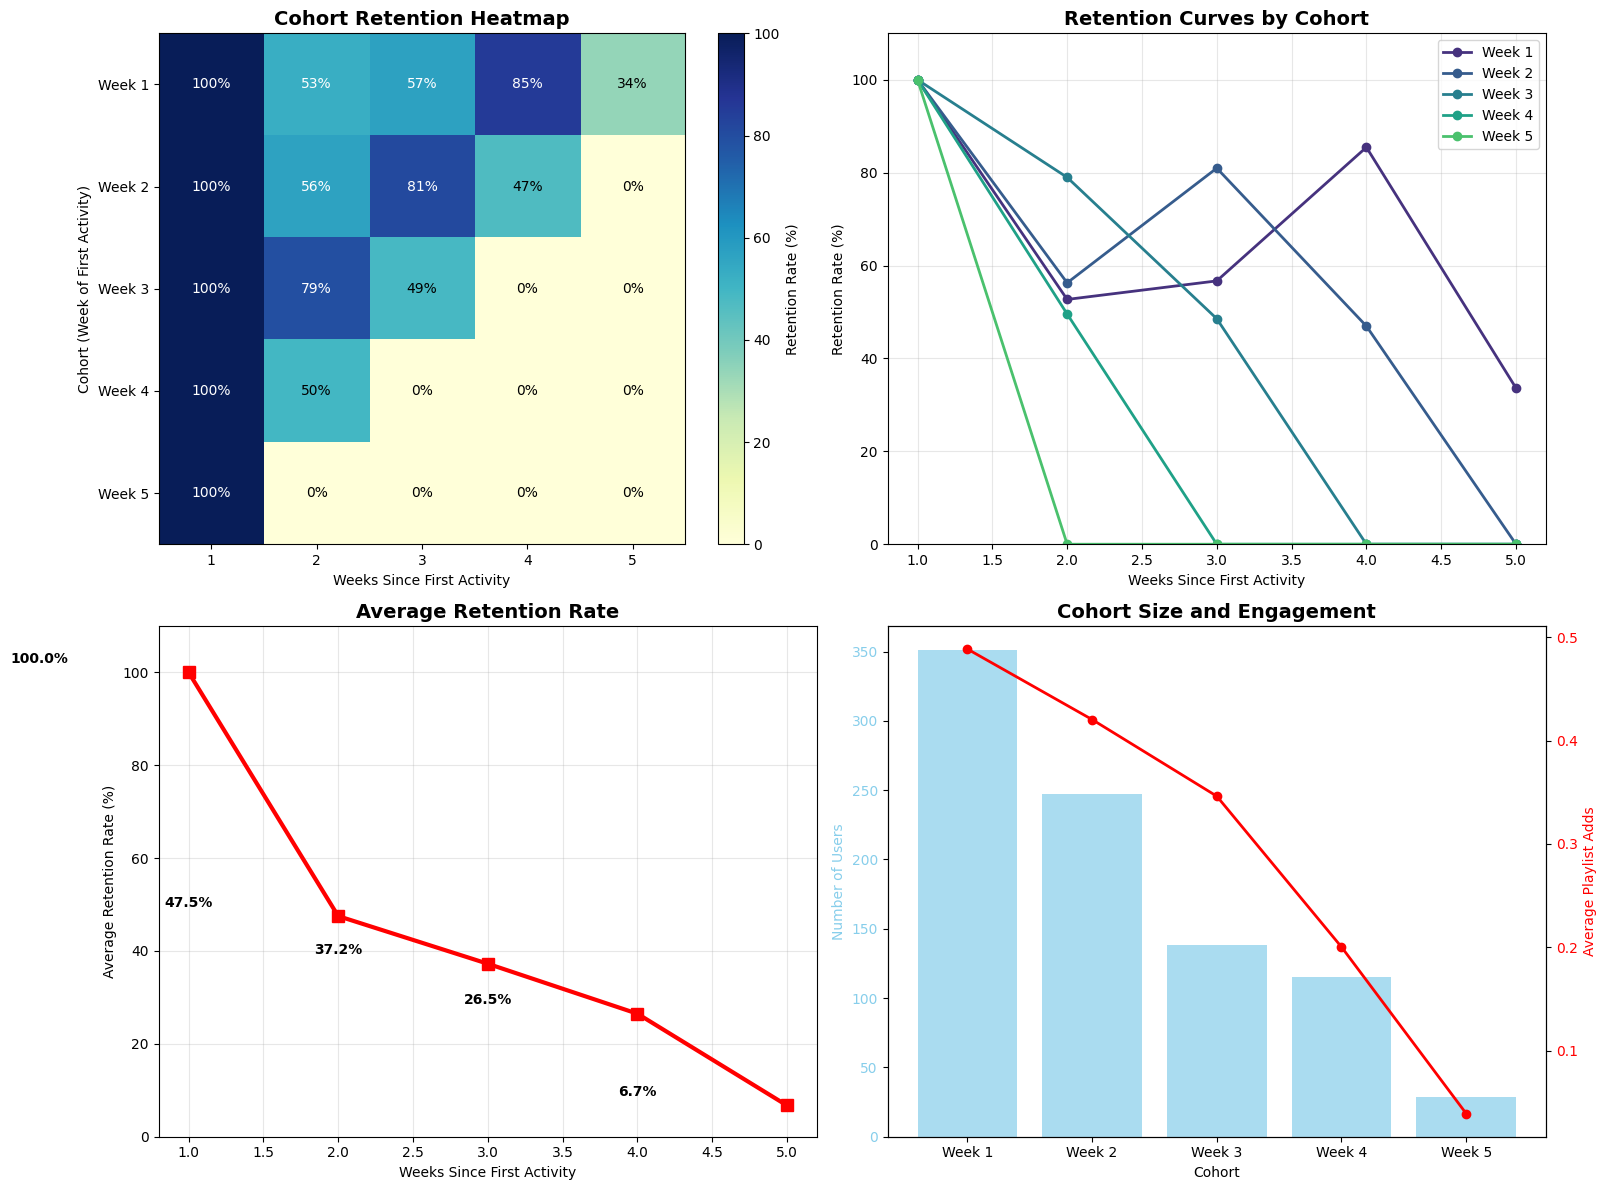


BEHAVIORAL COHORT ANALYSIS

Retention by Engagement Cohort:
activity_week          1      2      3     4     5
engagement_cohort                                 
High Engagers      100.0  100.0  100.0   0.0   0.0
Low Engagers       100.0   52.9   53.4  47.3  12.7
Medium Engagers    100.0   68.1   50.6  47.5  16.9

REVENUE COHORT ANALYSIS

Average Revenue per User by Cohort:
        users  avg_revenue
cohort                    
Week 1    351        19.85
Week 2    247        19.38
Week 3    138        20.89
Week 4    115        19.70
Week 5     29        14.74

SURVIVAL ANALYSIS

Survival Analysis by Cohort:
   cohort  survival_rate  avg_survival_time  users
0  Week 4          77.39               30.0    115
1  Week 1          76.92               30.0    351
2  Week 2          76.11               30.0    247
3  Week 3          80.43               30.0    138
4  Week 5          89.66               30.0     29

Ключевые расчеты
1. Overall Average Retention: 43.6%
2. Best Performing Cohor

/tmp/ipython-input-960359569.py:224: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  survival_df['churned'] = survival_df['churned'].fillna(False)


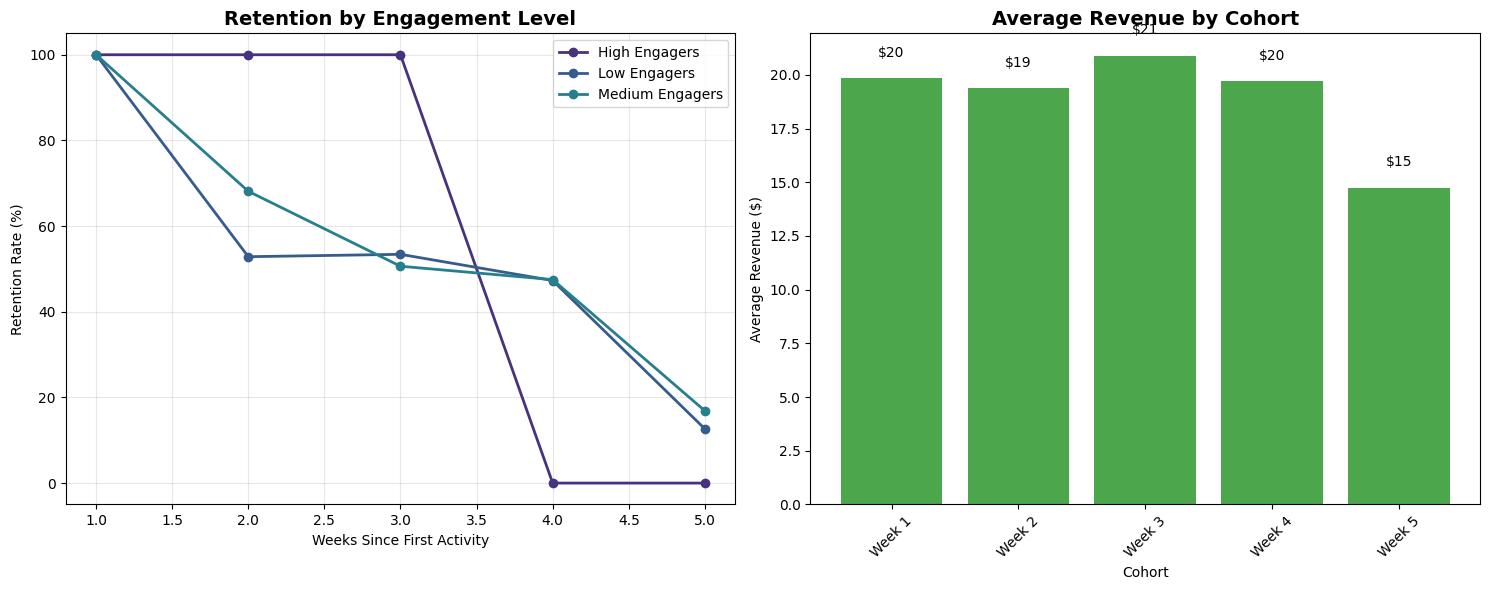

In [ ]:
import seaborn as sns
from datetime import datetime, timedelta
import matplotlib.colors as mcolors
from scipy.stats import chi2_contingency

# Set style for plots
plt.style.use('default')
sns.set_palette("viridis")

# Используем df_user_events для анализа когорт
df = df_user_events

# Convert day_since_start to datetime (предполагаем, что 0 это фикс дата начала)
base_date = datetime(2025, 1, 1)
df['date'] = df['day_since_start'].apply(lambda x: base_date + timedelta(days=x))

# 1.Когортный анализ на основании порядкоговог номера дня первой активности
print("COHORT ANALYSIS: USER RETENTION PATTERNS")
print("=" * 60)

# Ищем день первой активности (first trial start or purchase)
user_first_activity = df[
    (df['event'] == 'start_premium_trial') |
    (df['event'].str.contains('purchase_'))
].groupby('user_id')['day_since_start'].min().reset_index()
user_first_activity.columns = ['user_id', 'first_activity_day']

# Сравниваем с 0
cohort_df = df.merge(user_first_activity, on='user_id')

# СОздаем когорты (based on first activity)
cohort_df['cohort'] = cohort_df['first_activity_day'].apply(
    lambda x: f"Week {(x // 7) + 1}" if x <= 30 else "Other"
)

# Calculate activity period (weeks since first activity)
cohort_df['activity_week'] = ((cohort_df['day_since_start'] - cohort_df['first_activity_day']) // 7) + 1

# Filter for relevant weeks (1-5 weeks)
cohort_df = cohort_df[cohort_df['activity_week'].between(1, 5)]

# 2. Cohort Retention Analysis
cohort_pivot = cohort_df.pivot_table(
    index='cohort',
    columns='activity_week',
    values='user_id',
    aggfunc=pd.Series.nunique,
    fill_value=0
)

# Calculate retention rates
cohort_size = cohort_pivot.iloc[:, 0]
retention_pivot = cohort_pivot.divide(cohort_size, axis=0) * 100

print("\nCohort Sizes (Number of Users):")
print(cohort_size)
print("\nRetention Matrix (% of Cohort Active Each Week):")
print(retention_pivot.round(1))

# 3. Визуализация
fig, ((ax1, ax2), (ax3, ax4)) = plt.subplots(2, 2, figsize=(16, 12))

# Cohort Retention Heatmap
im = ax1.imshow(retention_pivot.values, cmap='YlGnBu', aspect='auto', vmin=0, vmax=100)
ax1.set_title('Cohort Retention Heatmap', fontsize=14, fontweight='bold')
ax1.set_xlabel('Weeks Since First Activity')
ax1.set_ylabel('Cohort (Week of First Activity)')
ax1.set_xticks(range(len(retention_pivot.columns)))
ax1.set_xticklabels(retention_pivot.columns)
ax1.set_yticks(range(len(retention_pivot.index)))
ax1.set_yticklabels(retention_pivot.index)

# Add values to heatmap
for i in range(len(retention_pivot.index)):
    for j in range(len(retention_pivot.columns)):
        text = ax1.text(j, i, f'{retention_pivot.iloc[i, j]:.0f}%',
                       ha="center", va="center", color="white" if retention_pivot.iloc[i, j] > 50 else "black")

plt.colorbar(im, ax=ax1, label='Retention Rate (%)')

# 4. Кривая Retentionпо когортам
for cohort in retention_pivot.index:
    ax2.plot(retention_pivot.columns, retention_pivot.loc[cohort],
            marker='o', label=cohort, linewidth=2)

ax2.set_title('Retention Curves by Cohort', fontsize=14, fontweight='bold')
ax2.set_xlabel('Weeks Since First Activity')
ax2.set_ylabel('Retention Rate (%)')
ax2.legend()
ax2.grid(True, alpha=0.3)
ax2.set_ylim(0, 110)

# 5. Средний Retention Rate
avg_retention = retention_pivot.mean()
ax3.plot(avg_retention.index, avg_retention.values,
        marker='s', color='red', linewidth=3, markersize=8)
ax3.set_title('Average Retention Rate', fontsize=14, fontweight='bold')
ax3.set_xlabel('Weeks Since First Activity')
ax3.set_ylabel('Average Retention Rate (%)')
ax3.grid(True, alpha=0.3)
ax3.set_ylim(0, 110)

# Add values to average retention plot
for i, value in enumerate(avg_retention.values):
    ax3.text(i, value + 2, f'{value:.1f}%', ha='center', fontweight='bold')

# 6. Cohort Size and Quality Analysis
# Сначала создадим метрику playlist_adds
cohort_df['playlist_adds'] = (cohort_df['event'] == 'add_to_playlist').astype(int)

cohort_quality = cohort_df.groupby('cohort').agg({
    'user_id': 'nunique',
    'playlist_adds': 'mean'
}).reset_index()
cohort_quality.columns = ['Cohort', 'Users', 'Avg_Playlist_Adds']

ax4.bar(cohort_quality['Cohort'], cohort_quality['Users'],
       color='skyblue', alpha=0.7, label='Number of Users')
ax4.set_title('Cohort Size and Engagement', fontsize=14, fontweight='bold')
ax4.set_xlabel('Cohort')
ax4.set_ylabel('Number of Users', color='skyblue')
ax4.tick_params(axis='y', labelcolor='skyblue')

ax4_2 = ax4.twinx()
ax4_2.plot(cohort_quality['Cohort'], cohort_quality['Avg_Playlist_Adds'],
          color='red', marker='o', linewidth=2, markersize=6, label='Avg Playlist Adds')
ax4_2.set_ylabel('Average Playlist Adds', color='red')
ax4_2.tick_params(axis='y', labelcolor='red')

plt.tight_layout()
plt.show()

# 7. Advanced Cohort Analysis - Behavioral Segmentation
print("\n" + "=" * 60)
print("BEHAVIORAL COHORT ANALYSIS")
print("=" * 60)

# Create behavioral cohorts based on initial engagement
def categorize_engagement(user_data):
    """Categorize users based on their initial engagement"""
    first_week_events = user_data[user_data['day_since_start'] <= user_data['first_activity_day'].iloc[0] + 7]
    playlist_adds = len(first_week_events[first_week_events['event'] == 'add_to_playlist'])

    if playlist_adds >= 5:
        return 'High Engagers'
    elif playlist_adds >= 2:
        return 'Medium Engagers'
    else:
        return 'Low Engagers'

# Apply engagement categorization
engagement_cohorts = []
for user_id in cohort_df['user_id'].unique():
    user_data = cohort_df[cohort_df['user_id'] == user_id]
    engagement = categorize_engagement(user_data)
    engagement_cohorts.append({'user_id': user_id, 'engagement_cohort': engagement})

engagement_df = pd.DataFrame(engagement_cohorts)
cohort_df = cohort_df.merge(engagement_df, on='user_id')

# Analyze retention by engagement cohort
engagement_retention = cohort_df.pivot_table(
    index='engagement_cohort',
    columns='activity_week',
    values='user_id',
    aggfunc=pd.Series.nunique,
    fill_value=0
)

engagement_size = engagement_retention.iloc[:, 0]
engagement_retention_pct = engagement_retention.divide(engagement_size, axis=0) * 100

print("\nRetention by Engagement Cohort:")
print(engagement_retention_pct.round(1))

# 8. Revenue Cohort Analysis
print("\n" + "=" * 60)
print("REVENUE COHORT ANALYSIS")
print("=" * 60)

# Map purchase types to revenue values
revenue_map = {
    'purchase_monthly': 10,
    'purchase_quarterly': 25,
    'purchase_annual': 80
}

# Calculate revenue per user
revenue_events = df[df['event'].str.contains('purchase')].copy()
revenue_events['revenue'] = revenue_events['event'].map(revenue_map)

user_revenue = revenue_events.groupby('user_id')['revenue'].sum().reset_index()
cohort_revenue_df = cohort_df.merge(user_revenue, on='user_id', how='left').fillna(0)

# Calculate average revenue per cohort
cohort_revenue = cohort_revenue_df.groupby('cohort').agg({
    'user_id': 'nunique',
    'revenue': 'mean'
}).round(2)

cohort_revenue.columns = ['users', 'avg_revenue']
print("\nAverage Revenue per User by Cohort:")
print(cohort_revenue)

# 9. Survival Analysis
print("\n" + "=" * 60)
print("SURVIVAL ANALYSIS")
print("=" * 60)

# Calculate when users churned (if they did)
user_outcomes = df[df['event'].isin(['renew', 'cancel'])].groupby('user_id').agg({
    'event': 'last',
    'day_since_start': 'max'
}).reset_index()

user_outcomes['churned'] = user_outcomes['event'] == 'cancel'
user_outcomes['survival_time'] = user_outcomes['day_since_start']

# Merge with cohort data
survival_df = cohort_df.merge(user_outcomes[['user_id', 'churned', 'survival_time']],
                            on='user_id', how='left').drop_duplicates('user_id')

# Заполним пропущенные значения - если нет данных о churn, считаем что пользователь не отменил
survival_df['churned'] = survival_df['churned'].fillna(False)

# Calculate survival probability by cohort
cohort_survival = []
for cohort in survival_df['cohort'].unique():
    cohort_data = survival_df[survival_df['cohort'] == cohort]
    survived = len(cohort_data[cohort_data['churned'] == False])  # Явное сравнение вместо ~
    total = len(cohort_data)
    survival_rate = (survived / total) * 100 if total > 0 else 0
    cohort_survival.append({
        'cohort': cohort,
        'survival_rate': survival_rate,
        'avg_survival_time': cohort_data['survival_time'].mean(),
        'users': total
    })

survival_summary = pd.DataFrame(cohort_survival)
print("\nSurvival Analysis by Cohort:")
print(survival_summary.round(2))

# 10. Final Insights and Recommendations
print("\n" + "=" * 60)
print("Ключевые расчеты")
print("=" * 60)

# Calculate key metrics
overall_retention = retention_pivot.mean().mean()
best_cohort = retention_pivot.mean(axis=1).idxmax()
worst_cohort = retention_pivot.mean(axis=1).idxmin()
engagement_impact = (engagement_retention_pct.loc['High Engagers'] - engagement_retention_pct.loc['Low Engagers']).mean()

print(f"1. Overall Average Retention: {overall_retention:.1f}%")
print(f"2. Best Performing Cohort: {best_cohort} ({retention_pivot.mean(axis=1)[best_cohort]:.1f}% retention)")
print(f"3. Worst Performing Cohort: {worst_cohort} ({retention_pivot.mean(axis=1)[worst_cohort]:.1f}% retention)")
print(f"4. Engagement Impact: High engagers retain {engagement_impact:.1f}% better than low engagers")
print(f"5. Average Revenue per User: ${cohort_revenue['avg_revenue'].mean():.2f}")


# Additional visualization for engagement cohorts
fig, ax = plt.subplots(1, 2, figsize=(15, 6))

# Engagement cohort retention
for cohort in engagement_retention_pct.index:
    ax[0].plot(engagement_retention_pct.columns, engagement_retention_pct.loc[cohort],
              marker='o', label=cohort, linewidth=2)

ax[0].set_title('Retention by Engagement Level', fontsize=14, fontweight='bold')
ax[0].set_xlabel('Weeks Since First Activity')
ax[0].set_ylabel('Retention Rate (%)')
ax[0].legend()
ax[0].grid(True, alpha=0.3)

# Revenue by cohort
ax[1].bar(cohort_revenue.index, cohort_revenue['avg_revenue'],
         color='green', alpha=0.7)
ax[1].set_title('Average Revenue by Cohort', fontsize=14, fontweight='bold')
ax[1].set_xlabel('Cohort')
ax[1].set_ylabel('Average Revenue ($)')
ax[1].tick_params(axis='x', rotation=45)

# Add revenue values to bars
for i, value in enumerate(cohort_revenue['avg_revenue']):
    ax[1].text(i, value + 1, f'${value:.0f}', ha='center')

plt.tight_layout()
plt.show()

### Гипотезы для A/B тестов

- **Основные гипотезы для  A/B тестов:**

H₀: Внедрение новой рекомендательной системы не влияет на ключевые метрики вовлеченности и монетизации пользователей

H₁: Новая рекомендательная система улучшает вовлеченность (add_to_playlist_count, active_days) и монетизацию (ARPU, Renewal Rate) пользователей

-  Для общей выборки paid пользователей:
H₀: ARPU_paid_test = ARPU_paid_control  
H₁: ARPU_paid_test ≠ ARPU_paid_control

H₀: Renewal_rate_test = Renewal_rate_control  
H₁: Renewal_rate_test ≠ Renewal_rate_control

- Для высокоактивных paid пользователей (сегмент "Paid active"):
H₀: Active_days_test = Active_days_control  
H₁: Active_days_test ≠ Active_days_control *(p_value = 0.044742 < 0.05 → ОТКЛОНЯЕМ H₀!)*

H₀: Add_to_playlist_count_test = Add_to_playlist_count_control  
H₁: Add_to_playlist_count_test ≠ Add_to_playlist_count_control

> Проверка гипотез не множественная, все тесты проводятся отдельно, вывод по метрикам делается отдельно

### ARPU, Conversion, LTV, Retention для полной выборки


In [ ]:
import pandas as pd
import numpy as np
from scipy.stats import ttest_ind, mannwhitneyu, chi2_contingency, fisher_exact

# ======================
# Загрузка данных
# ======================
df_sub = pd.read_csv('/content/subscription_plans_and_retention.csv')
df = pd.read_csv('/content/user_event_data_streaming_mini.csv')

purchase_events = ['purchase_monthly','purchase_quarterly','purchase_annual']
purchase_events_all = purchase_events + ['renew']  # для paid-флага/retention

# ======================
# Маппинги планов
# ======================
price_map = df_sub.set_index('plan')['price_usd'].to_dict()
ret1_map  = df_sub.set_index('plan')['retention_1m'].to_dict()
ret3_map  = df_sub.set_index('plan')['retention_3m'].to_dict()
ret6_map  = df_sub.set_index('plan')['retention_6m'].to_dict()
ads_map   = df_sub.set_index('plan')['arpu_ads_usd'].to_dict()

# ======================
# Пользовательские признаки
# ======================
# группа
user_group = df.groupby('user_id')['group'].first()

# план (по первой покупке)
def first_plan(user_df):
    tmp = user_df[['event','day_since_start']].sort_values('day_since_start')
    first_p = tmp[tmp['event'].isin(purchase_events)].head(1)
    if first_p.empty:
        return 'Free'
    return {'purchase_monthly':'Monthly',
            'purchase_quarterly':'Quarterly',
            'purchase_annual':'Annual'}[first_p.iloc[0]['event']]

user_plan = df.groupby('user_id')[['event','day_since_start']].apply(first_plan)

# conversion: был ли факт первой покупки (исключая renew)
conversion_flag = (
    df.groupby('user_id')['event']
      .apply(lambda s: s.isin(purchase_events).any())
      .astype(int)
      .rename('conversion_flag')
)

# retention (факт продления): наличие 'renew'
retention_flag = (
    df.groupby('user_id')['event']
      .apply(lambda s: (s == 'renew').any())
      .astype(int)
      .rename('retention_flag')
)

# ======================
# ARPU и LTV на 6м горизонте
# ======================
# ARPU: для Free = 0 (если хочешь учитывать рекламу — поменяй на ads_map['Free'])
def user_arpu(uid):
    plan = user_plan.loc[uid]
    if plan == 'Free':
        return 0.0
    return float(price_map.get(plan, 0.0)) * float(ret6_map.get(plan, 0.0))

# LTV: во всей логике выше он совпадает с ARPU_6m;
# если хочешь отделить, можно, например, для Free взять ads_map['Free'] * ret6_map['Free'].
def user_ltv(uid):
    plan = user_plan.loc[uid]
    if plan == 'Free':
        # Если нужно учитывать рекламный вклад для фри, раскомментируй строку ниже и закомментируй "return 0.0"
        # return float(ads_map.get('Free', 0.0)) * float(ret6_map.get('Free', 0.0))
        return 0.0
    return float(price_map.get(plan, 0.0)) * float(ret6_map.get(plan, 0.0))

ARPU = pd.Series({uid: user_arpu(uid) for uid in user_plan.index}, name='ARPU')
LTV  = pd.Series({uid: user_ltv(uid)  for uid in user_plan.index}, name='LTV')

# ======================
# Сборка пользовательской таблицы
# ======================
users = pd.concat([user_group, user_plan.rename('plan'),
                   conversion_flag, retention_flag, ARPU, LTV], axis=1).reset_index().rename(columns={'index':'user_id'})

# ======================
# Функции для p-values
# ======================
def p_ttest_welch(a, b):
    a = pd.Series(a).dropna()
    b = pd.Series(b).dropna()
    if len(a) > 1 and len(b) > 1:
        _, p = ttest_ind(a, b, equal_var=False)  # двухсторонний Welch
        return p
    return np.nan

def p_chi2_fisher(tbl):
    """Возвращает (p_chi2, p_fisher) для 2x2 таблицы."""
    if tbl.shape == (2, 2):
        _, p_chi, _, _ = chi2_contingency(tbl)
        _, p_f = fisher_exact(tbl)
        return p_chi, p_f
    return np.nan, np.nan

# ======================
# A/B по всей выборке (test vs control)
# ======================
test_mask = users['group'] == 'test'
ctrl_mask = users['group'] == 'control'

# 1) ARPU
p_arpu = p_ttest_welch(users.loc[test_mask, 'ARPU'], users.loc[ctrl_mask, 'ARPU'])

# 2) Conversion (первичная покупка)
conv_tbl = pd.crosstab(users['group'], users['conversion_flag'])
p_conv_chi, p_conv_fisher = p_chi2_fisher(conv_tbl)

# 3) LTV (6m)
p_ltv = p_ttest_welch(users.loc[test_mask, 'LTV'], users.loc[ctrl_mask, 'LTV'])

# 4) Retention (renew)
ret_tbl = pd.crosstab(users['group'], users['retention_flag'])
p_ret_chi, p_ret_fisher = p_chi2_fisher(ret_tbl)

# ======================
# Сводная таблица метрик и значимости
# ======================
summary = pd.DataFrame({
    'Metric': ['ARPU (6m)', 'Conversion (any first purchase)', 'LTV (6m)', 'Retention (renew)'],
    'Test_mean': [
        users.loc[test_mask, 'ARPU'].mean(),
        users.loc[test_mask, 'conversion_flag'].mean(),
        users.loc[test_mask, 'LTV'].mean(),
        users.loc[test_mask, 'retention_flag'].mean()
    ],
    'Control_mean': [
        users.loc[ctrl_mask, 'ARPU'].mean(),
        users.loc[ctrl_mask, 'conversion_flag'].mean(),
        users.loc[ctrl_mask, 'LTV'].mean(),
        users.loc[ctrl_mask, 'retention_flag'].mean()
    ],
    'Welch_ttest_p': [p_arpu, np.nan, p_ltv, np.nan],
    'Chi2_p':        [np.nan, p_conv_chi, np.nan, p_ret_chi],
    'Fisher_p':      [np.nan, p_conv_fisher, np.nan, p_ret_fisher]
})

print("A/B по всей выборке (test vs control):")
print(summary)

# (необязательно) показать сами 2x2 матрицы
print("\nContingency — Conversion:\n", conv_tbl)
print("\nContingency — Retention:\n", ret_tbl)


A/B по всей выборке (test vs control):
                            Metric  Test_mean  Control_mean  Welch_ttest_p  \
0                        ARPU (6m)  11.238274     11.327712        0.93752   
1  Conversion (any first purchase)   0.890438      0.862069            NaN   
2                         LTV (6m)  11.238274     11.327712        0.93752   
3                Retention (renew)   0.695219      0.663286            NaN   

     Chi2_p  Fisher_p  
0       NaN       NaN  
1  0.206586  0.178893  
2       NaN       NaN  
3  0.311938  0.308240  

Contingency — Conversion:
 conversion_flag   0    1
group                   
control          68  425
test             55  447

Contingency — Retention:
 retention_flag    0    1
group                   
control         166  327
test            153  349


### Дополнительно разбираем платных пользователей.

- Paid active – платные пользователи с высокой активностью.
- Paid low_engagement – платные пользователи с низкой активностью.
- Churned active – отток, но были активные.
- Churned low_engagement – отток, но малоактивные.

In [ ]:
# Загрузка файлов
df_subscription = pd.read_csv('/content/subscription_plans_and_retention.csv')
df_user_events = pd.read_csv('/content/user_event_data_streaming_mini.csv')
print("✅ с кайфом загрузили данные !")

✅ с кайфом загрузили данные !


In [ ]:
# Список платных событий
purchase_events = ['purchase_quarterly', 'purchase_annual', 'purchase_monthly', 'renew']

# Функция классификации пользователей
def classify_user(user_data):
    events = user_data['event'].tolist()
    user_id = user_data['user_id'].iloc[0]

    has_paid = any(event in purchase_events for event in events)
    has_cancel = 'cancel' in events
    activity_count = events.count('add_to_playlist')

    # Определяем активность
    is_active = activity_count >= 3

    if has_cancel and has_paid:
        return 'Churned active' if is_active else 'Churned low_engagement'
    elif has_paid:
        return 'Paid active' if is_active else 'Paid low_engagement'
    else:
        return 'Free/Other'  # если не платил и не отменял

# Применяем сегментацию
user_segments = df_user_events.groupby('user_id').apply(classify_user).reset_index()
user_segments.columns = ['user_id', 'segment']

# Объединяем с исходными данными
df_user_events = df_user_events.merge(user_segments, on='user_id')

# Распределение сегментов
segment_distribution = user_segments['segment'].value_counts()
print("Распределение пользователей по сегментам:")
print(segment_distribution)

# Анализ сегментов по группам (test/control)
segment_group_analysis = pd.crosstab(user_segments['segment'], df_user_events.groupby('user_id')['group'].first())
print("\nРаспределение сегментов по группам:")
print(segment_group_analysis)

# Анализ контента
content_segment_analysis = pd.crosstab(
    user_segments['segment'],
    df_user_events.groupby('user_id')['content_segment'].agg(lambda x: x.mode()[0] if not x.mode().empty else 'Unknown')
)
print("\nСвязь сегментов пользователей с сегментами контента:")
print(content_segment_analysis)

# Анализ оттока
churn_users = user_segments[user_segments['segment'].str.contains('Churned')]
print(f"\nОбщее количество оттока: {len(churn_users)}")

churn_analysis = pd.crosstab(
    churn_users['segment'],
    df_user_events[df_user_events['user_id'].isin(churn_users['user_id'])].groupby('user_id')['group'].first()
)
print("\nАнализ оттока по группам:")
print(churn_analysis)


/tmp/ipython-input-887799274.py:24: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  user_segments = df_user_events.groupby('user_id').apply(classify_user).reset_index()


Распределение пользователей по сегментам:
segment
Paid active               409
Paid low_engagement       267
Free/Other                123
Churned active            119
Churned low_engagement     77
Name: count, dtype: int64

Распределение сегментов по группам:
group                   control  test
segment                              
Churned active               58    61
Churned low_engagement       39    37
Free/Other                   62    61
Paid active                 208   197
Paid low_engagement         125   141

Связь сегментов пользователей с сегментами контента:
content_segment         All  Mix  Music  Podcast
segment                                         
Churned active           62    5     40       12
Churned low_engagement   40    7     17       12
Free/Other               66    7     31       19
Paid active             227   31    115       32
Paid low_engagement     150   19     63       34

Общее количество оттока: 196

Анализ оттока по группам:
group            

In [ ]:
import pandas as pd
import numpy as np
from scipy.stats import ttest_ind, mannwhitneyu, chi2_contingency, fisher_exact

# Загрузка
df_sub = pd.read_csv('/content/subscription_plans_and_retention.csv')
df = pd.read_csv('/content/user_event_data_streaming_mini.csv')

purchase_events = ['purchase_quarterly','purchase_annual','purchase_monthly','renew']

# карты цен и retention для ARPU
price_map = df_sub.set_index('plan')['price_usd'].to_dict()
ret6_map  = df_sub.set_index('plan')['retention_6m'].to_dict()

# признаки пользователя
user_active_days = df.groupby('user_id')['day_since_start'].nunique().rename('active_days')
user_events = df.groupby('user_id')['event'].apply(list)
add_cnt = user_events.apply(lambda ev: ev.count('add_to_playlist')).rename('add_to_playlist_count')
has_paid = user_events.apply(lambda ev: any(e in purchase_events for e in ev)).rename('has_paid')

# renew флаг
renew_flag = (df[df['event']=='renew'].groupby('user_id').size()
              .reindex(df['user_id'].unique(), fill_value=0))
renew_flag = (renew_flag>0).astype(int).rename('renew_flag')

# план по первой покупке
def first_plan(user_df):
    tmp = user_df[['event','day_since_start']].sort_values('day_since_start')
    first_p = tmp[tmp['event'].isin(['purchase_monthly','purchase_quarterly','purchase_annual'])].head(1)
    if first_p.empty: return 'Free'
    return {'purchase_monthly':'Monthly',
            'purchase_quarterly':'Quarterly',
            'purchase_annual':'Annual'}[first_p.iloc[0]['event']]

user_plan = df.groupby('user_id')[['event','day_since_start']].apply(first_plan).rename('plan')

# ARPU_paid
def user_arpu(uid):
    plan = user_plan.loc[uid]
    if plan=='Free': return 0.0
    return float(price_map.get(plan,0.0)) * float(ret6_map.get(plan,0.0))
arpu_paid = pd.Series({uid:user_arpu(uid) for uid in df['user_id'].unique()}, name='ARPU_paid')

# база пользователей
users = pd.DataFrame({
    'active_days': user_active_days,
    'add_to_playlist_count': add_cnt,
    'has_paid': has_paid,
    'plan': user_plan,
    'renew_flag': renew_flag,
    'ARPU_paid': arpu_paid
}).reset_index().rename(columns={'index':'user_id'})

# группа
users = users.merge(df[['user_id','group']].drop_duplicates(), on='user_id', how='left')

# сегментация: только paid
def classify_paid(row):
    if not row['has_paid']:
        return None
    return 'Paid active' if row['add_to_playlist_count'] >= 4 else 'Paid low_engagement'

users['segment'] = users.apply(classify_paid, axis=1)
users = users.dropna(subset=['segment'])

# ===== Метрики =====
def seg_metrics(sub):
    return pd.Series({
        'n_users': len(sub),
        'ARPU_paid_mean': sub['ARPU_paid'].mean(),
        'Renewal_rate': sub['renew_flag'].mean(),
        'Active_days_paid_mean': sub['active_days'].mean()
    })

summary = users.groupby(['segment','group']).apply(seg_metrics).reset_index()

# Добавляем объединённый Paid (all)
paid_all = users.copy()
paid_all['segment'] = 'Paid (all)'
summary_all = paid_all.groupby(['segment','group']).apply(seg_metrics).reset_index()

summary = pd.concat([summary, summary_all], ignore_index=True)

# ===== Значимость test vs control =====
sig = []
for seg in summary['segment'].unique():
    sub = users.copy()
    if seg == 'Paid (all)':
        sub = users  # берём всех paid
    else:
        sub = users[users['segment']==seg]

    test = sub[sub['group']=='test']
    ctrl = sub[sub['group']=='control']

    # Welch t-test для ARPU
    if len(test)>1 and len(ctrl)>1:
        _, p_arpu = ttest_ind(test['ARPU_paid'], ctrl['ARPU_paid'], equal_var=False)
    else:
        p_arpu = np.nan

    # Renewal rate → chi2/fisher
    tbl = pd.crosstab(sub['group'], sub['renew_flag'])
    if tbl.shape==(2,2):
        chi2, p_chi, _, _ = chi2_contingency(tbl)
        _, p_fisher = fisher_exact(tbl)
    else:
        p_chi = p_fisher = np.nan

    # Active days → Mann–Whitney
    if len(test)>0 and len(ctrl)>0:
        _, p_days = mannwhitneyu(test['active_days'], ctrl['active_days'],alternative="two-sided")
    else:
        p_days = np.nan

    sig.append({
        'segment': seg,
        'p_ARPU': p_arpu,
        'p_Renewal_chi2': p_chi,
        'p_Renewal_fisher': p_fisher,
        'p_Active_days': p_days
    })

signif = pd.DataFrame(sig)
final = summary.merge(signif, on='segment', how='left').sort_values(['segment','group'])

final


/tmp/ipython-input-1929882916.py:75: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  summary = users.groupby(['segment','group']).apply(seg_metrics).reset_index()
/tmp/ipython-input-1929882916.py:80: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  summary_all = paid_all.groupby(['segment','group']).apply(seg_metrics).reset_index()


,segment,group,n_users,ARPU_paid_mean,Renewal_rate,Active_days_paid_mean,p_ARPU,p_Renewal_chi2,p_Renewal_fisher,p_Active_days
4,Paid (all),control,425.0,13.140145,0.769412,5.247059,0.682070,0.748864,0.745540,0.866943
5,Paid (all),test,447.0,12.621059,0.780761,5.205817,0.682070,0.748864,0.745540,0.866943
0,Paid active,control,145.0,14.011858,0.800000,7.000000,0.518345,0.880962,0.780642,0.044742
1,Paid active,test,164.0,12.581012,0.786585,6.737805,0.518345,0.880962,0.780642,0.044742
2,Paid low_engagement,control,280.0,12.688723,0.753571,4.339286,0.977032,0.570463,0.550859,0.752939
3,Paid low_engagement,test,283.0,12.644266,0.777385,4.318021,0.977032,0.570463,0.550859,0.752939


In [ ]:
import pandas as pd
import numpy as np
from scipy.stats import ttest_ind, mannwhitneyu, chi2_contingency, fisher_exact

# ===== Загрузка
df_sub = pd.read_csv('/content/subscription_plans_and_retention.csv')
df = pd.read_csv('/content/user_event_data_streaming_mini.csv')

purchase_events = ['purchase_monthly','purchase_quarterly','purchase_annual','renew']

# ===== Единый список пользователей
all_users = df['user_id'].unique()

# ===== Карты цен/ретенции для ARPU
price_map = df_sub.set_index('plan')['price_usd'].to_dict()
ret6_map  = df_sub.set_index('plan')['retention_6m'].to_dict()

# ===== Базовые пер-ки на пользователя (строго по единому списку)
active_days = df.groupby('user_id')['day_since_start'].nunique().reindex(all_users, fill_value=0)

add_cnt = (
    df.groupby('user_id')['event']
      .apply(lambda s: (s == 'add_to_playlist').sum())
      .reindex(all_users, fill_value=0)
)

has_paid = (
    df.groupby('user_id')['event']
      .apply(lambda s: s.isin(purchase_events).any())
      .reindex(all_users, fill_value=False)
)

has_cancel = (
    df.groupby('user_id')['event']
      .apply(lambda s: (s == 'cancel').any())
      .reindex(all_users, fill_value=False)
)

renew_flag = (
    df.groupby('user_id')['event']
      .apply(lambda s: (s == 'renew').any())
      .astype(int)
      .reindex(all_users, fill_value=0)
)

group_map = df.groupby('user_id')['group'].first().reindex(all_users)

# план по первой покупке (или 'Free', если не покупал)
def _first_plan(g):
    tmp = g[['event','day_since_start']].sort_values('day_since_start')
    fp = tmp[tmp['event'].isin(['purchase_monthly','purchase_quarterly','purchase_annual'])].head(1)
    if fp.empty: return 'Free'
    return {'purchase_monthly':'Monthly','purchase_quarterly':'Quarterly','purchase_annual':'Annual'}[fp.iloc[0]['event']]

plan = (
    df.groupby('user_id')[['event','day_since_start']]
      .apply(_first_plan)
      .reindex(all_users, fill_value='Free')
)

# ARPU для платных (free = 0)
ARPU = pd.Series(
    [0.0 if p=='Free' else float(price_map.get(p,0.0)) * float(ret6_map.get(p,0.0)) for p in plan],
    index=all_users, name='ARPU'
)

# ===== Оставляем только paid ∪ churn (как ты просил: платные + отменившие)
mask_paid_or_churn = has_paid | has_cancel
flt_users = pd.Index(all_users)[mask_paid_or_churn.values]

# ===== Сегментация только по активности (≥4 — Active)
segment = pd.Series(
    np.where(add_cnt.loc[flt_users] >= 4, 'Paid+Churn Active', 'Paid+Churn Low_engagement'),
    index=flt_users, name='segment'
)

# ===== Собираем финальную «пользовательскую» таблицу
users = pd.DataFrame({
    'group': group_map.loc[flt_users],
    'active_days': active_days.loc[flt_users].astype(float),
    'add_to_playlist_count': add_cnt.loc[flt_users].astype(int),
    'renew_flag': renew_flag.loc[flt_users].astype(int),
    'ARPU': ARPU.loc[flt_users].astype(float),
    'segment': segment
}).reset_index().rename(columns={'index':'user_id'})

# ===== Метрики в разрезе segment × group
def seg_metrics(sub):
    return pd.Series({
        'n_users': len(sub),
        'ARPU_mean': sub['ARPU'].mean(),
        'Renewal_rate': sub['renew_flag'].mean(),
        'Active_days_mean': sub['active_days'].mean()
    })

summary = users.groupby(['segment','group'], as_index=False).apply(seg_metrics).reset_index(drop=True)

# ===== Значимость test vs control по каждой метрике внутри сегмента
sig_rows = []
for seg in summary['segment'].unique():
    sub = users[users['segment']==seg]
    test = sub[sub['group']=='test']
    ctrl = sub[sub['group']=='control']

    # Welch t-test для ARPU
    if len(test)>1 and len(ctrl)>1:
        _, p_arpu = ttest_ind(test['ARPU'], ctrl['ARPU'], equal_var=False)
    else:
        p_arpu = np.nan

    # Renewal rate → chi2 + Fisher (2x2)
    tbl = pd.crosstab(sub['group'], sub['renew_flag'])
    if tbl.shape==(2,2):
        _, p_chi, _, _ = chi2_contingency(tbl)
        _, p_fisher = fisher_exact(tbl)
    else:
        p_chi = p_fisher = np.nan

    # Active days → Mann-Whitney
    if len(test)>0 and len(ctrl)>0:
        _, p_days = mannwhitneyu(test['active_days'], ctrl['active_days'], alternative='two-sided')
    else:
        p_days = np.nan

    sig_rows.append({
        'segment': seg,
        'p_ARPU': p_arpu,
        'p_Renewal_chi2': p_chi,
        'p_Renewal_fisher': p_fisher,
        'p_Active_days': p_days
    })

signif = pd.DataFrame(sig_rows)
final = summary.merge(signif, on='segment', how='left').sort_values(['segment','group'])



# Дополнительно: быстро проверить, что базовые количества корректны
print("\nПроверка количества пользователей по сегментам (всего):")
print(users['segment'].value_counts())
print("\nПроверка количества пользователей по segment × group:")
print(pd.crosstab(users['segment'], users['group']))
final


Проверка количества пользователей по сегментам (всего):
segment
Paid+Churn Low_engagement    563
Paid+Churn Active            309
Name: count, dtype: int64

Проверка количества пользователей по segment × group:
group                      control  test
segment                                 
Paid+Churn Active              145   164
Paid+Churn Low_engagement      280   283


/tmp/ipython-input-597064117.py:96: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  summary = users.groupby(['segment','group'], as_index=False).apply(seg_metrics).reset_index(drop=True)


,segment,group,n_users,ARPU_mean,Renewal_rate,Active_days_mean,p_ARPU,p_Renewal_chi2,p_Renewal_fisher,p_Active_days
0,Paid+Churn Active,control,145.0,14.011858,0.800000,7.000000,0.518345,0.880962,0.780642,0.044742
1,Paid+Churn Active,test,164.0,12.581012,0.786585,6.737805,0.518345,0.880962,0.780642,0.044742
2,Paid+Churn Low_engagement,control,280.0,12.688723,0.753571,4.339286,0.977032,0.570463,0.550859,0.752939
3,Paid+Churn Low_engagement,test,283.0,12.644266,0.777385,4.318021,0.977032,0.570463,0.550859,0.752939


In [ ]:
from scipy.stats import ttest_ind

# маппинги
price_map = df_subscription.set_index("plan")["price_usd"].to_dict()
ret_map   = df_subscription.set_index("plan")["retention_6m"].to_dict()
ads_map   = df_subscription.set_index("plan")["arpu_ads_usd"].to_dict()


# фильтруем только Paid+Free trial active
seg = users[users['segment'].isin(['Paid active','Free trial active'])].copy()
seg['segment'] = 'Paid+Free trial active'

# считаем LTV
def user_ltv(uid):
    plan = user_plan.loc[uid]
    if plan == "Free":
        return ads_map["Free"] * ret_map["Free"]   # trial/free через рекламу
    return price_map.get(plan, 0) * ret_map.get(plan, 0)

seg["LTV"] = seg["user_id"].apply(user_ltv)

# группировка
ltv_summary = seg.groupby("group").agg(
    n_users=("user_id","count"),
    ARPU_mean=("ARPU_paid","mean"),
    LTV_mean=("LTV","mean")
).reset_index()

# Welch t-test
test_vals = seg[seg["group"]=="test"]["LTV"]
ctrl_vals = seg[seg["group"]=="control"]["LTV"]

if len(test_vals)>1 and len(ctrl_vals)>1:
    _, p_val = ttest_ind(test_vals, ctrl_vals, equal_var=False)
else:
    p_val = np.nan

ltv_summary["p_LTV_ttest"] = p_val

print("LTV для Paid+Free trial active (test vs control):")
print(ltv_summary)


LTV для Paid+Free trial active (test vs control):
     group  n_users  ARPU_mean   LTV_mean  p_LTV_ttest
0  control      147  13.821220  13.823057     0.548862
1     test      165  12.504764  12.505582     0.548862


In [ ]:
import pandas as pd
import numpy as np
from scipy.stats import ttest_ind, mannwhitneyu, chi2_contingency, fisher_exact

# ======================
# Загрузка данных
# ======================
df_sub = pd.read_csv('/content/subscription_plans_and_retention.csv')
df = pd.read_csv('/content/user_event_data_streaming_mini.csv')

purchase_events = ['purchase_monthly','purchase_quarterly','purchase_annual']
purchase_events_all = purchase_events + ['renew']  # для paid-флага/retention

# ======================
# Маппинги планов
# ======================
price_map = df_sub.set_index('plan')['price_usd'].to_dict()
ret1_map  = df_sub.set_index('plan')['retention_1m'].to_dict()
ret3_map  = df_sub.set_index('plan')['retention_3m'].to_dict()
ret6_map  = df_sub.set_index('plan')['retention_6m'].to_dict()
ads_map   = df_sub.set_index('plan')['arpu_ads_usd'].to_dict()

# ======================
# Пользовательские признаки
# ======================
# группа
user_group = df.groupby('user_id')['group'].first()

# план (по первой покупке)
def first_plan(user_df):
    tmp = user_df[['event','day_since_start']].sort_values('day_since_start')
    first_p = tmp[tmp['event'].isin(purchase_events)].head(1)
    if first_p.empty:
        return 'Free'
    return {'purchase_monthly':'Monthly',
            'purchase_quarterly':'Quarterly',
            'purchase_annual':'Annual'}[first_p.iloc[0]['event']]

user_plan = df.groupby('user_id')[['event','day_since_start']].apply(first_plan)

# conversion: был ли факт первой покупки (исключая renew)
conversion_flag = (
    df.groupby('user_id')['event']
      .apply(lambda s: s.isin(purchase_events).any())
      .astype(int)
      .rename('conversion_flag')
)

# retention (факт продления): наличие 'renew'
retention_flag = (
    df.groupby('user_id')['event']
      .apply(lambda s: (s == 'renew').any())
      .astype(int)
      .rename('retention_flag')
)

# ======================
# ARPU и LTV на 6м горизонте
# ======================
# ARPU: для Free = 0 (если хочешь учитывать рекламу — поменяй на ads_map['Free'])
def user_arpu(uid):
    plan = user_plan.loc[uid]
    if plan == 'Free':
        return 0.0
    return float(price_map.get(plan, 0.0)) * float(ret6_map.get(plan, 0.0))

# LTV: во всей логике выше он совпадает с ARPU_6m;
# если хочешь отделить, можно, например, для Free взять ads_map['Free'] * ret6_map['Free'].
def user_ltv(uid):
    plan = user_plan.loc[uid]
    if plan == 'Free':
        # Если нужно учитывать рекламный вклад для фри, раскомментируй строку ниже и закомментируй "return 0.0"
        # return float(ads_map.get('Free', 0.0)) * float(ret6_map.get('Free', 0.0))
        return 0.0
    return float(price_map.get(plan, 0.0)) * float(ret6_map.get(plan, 0.0))

ARPU = pd.Series({uid: user_arpu(uid) for uid in user_plan.index}, name='ARPU')
LTV  = pd.Series({uid: user_ltv(uid)  for uid in user_plan.index}, name='LTV')

# ======================
# Сборка пользовательской таблицы
# ======================
users = pd.concat([user_group, user_plan.rename('plan'),
                   conversion_flag, retention_flag, ARPU, LTV], axis=1).reset_index().rename(columns={'index':'user_id'})

# ======================
# Функции для p-values
# ======================
def p_ttest_welch(a, b):
    a = pd.Series(a).dropna()
    b = pd.Series(b).dropna()
    if len(a) > 1 and len(b) > 1:
        _, p = ttest_ind(a, b, equal_var=False)  # двухсторонний Welch
        return p
    return np.nan

def p_chi2_fisher(tbl):
    """Возвращает (p_chi2, p_fisher) для 2x2 таблицы."""
    if tbl.shape == (2, 2):
        _, p_chi, _, _ = chi2_contingency(tbl)
        _, p_f = fisher_exact(tbl)
        return p_chi, p_f
    return np.nan, np.nan

# ======================
# A/B по всей выборке (test vs control)
# ======================
test_mask = users['group'] == 'test'
ctrl_mask = users['group'] == 'control'

# 1) ARPU
p_arpu = p_ttest_welch(users.loc[test_mask, 'ARPU'], users.loc[ctrl_mask, 'ARPU'])

# 2) Conversion (первичная покупка)
conv_tbl = pd.crosstab(users['group'], users['conversion_flag'])
p_conv_chi, p_conv_fisher = p_chi2_fisher(conv_tbl)

# 3) LTV (6m)
p_ltv = p_ttest_welch(users.loc[test_mask, 'LTV'], users.loc[ctrl_mask, 'LTV'])

# 4) Retention (renew)
ret_tbl = pd.crosstab(users['group'], users['retention_flag'])
p_ret_chi, p_ret_fisher = p_chi2_fisher(ret_tbl)

# ======================
# Сводная таблица метрик и значимости
# ======================
summary = pd.DataFrame({
    'Metric': ['ARPU (6m)', 'Conversion (any first purchase)', 'LTV (6m)', 'Retention (renew)'],
    'Test_mean': [
        users.loc[test_mask, 'ARPU'].mean(),
        users.loc[test_mask, 'conversion_flag'].mean(),
        users.loc[test_mask, 'LTV'].mean(),
        users.loc[test_mask, 'retention_flag'].mean()
    ],
    'Control_mean': [
        users.loc[ctrl_mask, 'ARPU'].mean(),
        users.loc[ctrl_mask, 'conversion_flag'].mean(),
        users.loc[ctrl_mask, 'LTV'].mean(),
        users.loc[ctrl_mask, 'retention_flag'].mean()
    ],
    'Welch_ttest_p': [p_arpu, np.nan, p_ltv, np.nan],
    'Chi2_p':        [np.nan, p_conv_chi, np.nan, p_ret_chi],
    'Fisher_p':      [np.nan, p_conv_fisher, np.nan, p_ret_fisher]
})

print("A/B по всей выборке (test vs control):")
print(summary)

# (необязательно) показать сами 2x2 матрицы
print("\nContingency — Conversion:\n", conv_tbl)
print("\nContingency — Retention:\n", ret_tbl)


A/B по всей выборке (test vs control):
                            Metric  Test_mean  Control_mean  Welch_ttest_p  \
0                        ARPU (6m)  11.238274     11.327712        0.93752   
1  Conversion (any first purchase)   0.890438      0.862069            NaN   
2                         LTV (6m)  11.238274     11.327712        0.93752   
3                Retention (renew)   0.695219      0.663286            NaN   

     Chi2_p  Fisher_p  
0       NaN       NaN  
1  0.206586  0.178893  
2       NaN       NaN  
3  0.311938  0.308240  

Contingency — Conversion:
 conversion_flag   0    1
group                   
control          68  425
test             55  447

Contingency — Retention:
 retention_flag    0    1
group                   
control         166  327
test            153  349


### Выводы

- На общей выборке пользователей ключевые метрики (ARPU, конверсия, LTV, retention) после внедрения новой фичи **не изменились**.

- Тестирование по различным прокси метрикам на общей выборке не дало статистически значимых результатов, далее исследовалась наиболее активная категория пользователей

- При сегментации по активности выявлено, что среди наиболее вовлечённых пользователей (≈30% самых активных) наблюдается **снижение вовлечённости** — количество активных действий (add_to_playlist, active_days) в тесте статистически ниже, чем в контроле.
( p_value Active_days = 0.044742) < 0.05
   - Даже для выборки с Free_trial active пользователями и Paid_active пользователями ( p_Active_days = 0.049996 < 0.05)

  - При этом на конверсию в оплату и ARPU **статистически значимого влияния не обнаружено** 💸.

- Проверка LTV на горизонте (1м, 3м, 6м) показала, что он **тоже не снижается**, ни на общей выборке, ни в выделенном сегменте активных пользователей.

Новая рекомендационная система **снижает вовлечённость наиболее активных пользователей** 😢, не принося ощутимого роста монетизационных метрик.

Если целью внедрения является улучшение пользовательского опыта и удержания, а не PR-эффект, то фичу **НЕ СЛЕДУЕТ РЕЛИЗИТЬ** 🚫, так как рискуем потерять активных пользователей без роста выручки.

**Кратко: НЕ РЕЛИЗИМ!** ❌


> В тестах, где не было обнаружено статистически значимой разницы, следует учитывать, что объёма данных могло не хватить для достижения статистической мощности 80%. Это означает, что мы потенциально можем совершать ошибку II рода (не обнаружить реально существующий эффект). Однако наблюдаемые величины эффекта (аплифты) крайне малы, что позволяет заключить: даже если эффект и существует, его практическая значимость ничтожна